# 🫀 ECG Arrhythmia Classification — Part E: Deep Learning Classifiers

**Paper:** *An Efficient Multi-Scale CNN-BiLSTM with Dual Attention Mechanism for  
Real-Time Cardiac Arrhythmia Classification: Evaluation on MIT-BIH and PTB Databases*

---

## Where We Are in the Pipeline

```
Raw ECG (MIT-BIH, 360 Hz)
        │
        ▼
Part B — Preprocessing ✓
        │
        ▼
Part C — EMD Feature Extraction ✓
        │
        ▼
Part D — Split · MRMR · S-SMOTE ✓
        │   (X_beats_train/test.npy  ← raw waveforms)
        ▼
┌───────────────────────────────────────────────────┐
│  Part E — Deep Learning Classifiers  ◀ YOU ARE HERE│
│  • Full-class balanced SMOTE on raw waveforms      │
│  • CNN (1-D convolutional)                         │
│  • BiLSTM (bidirectional LSTM)                     │
│  • CNN-BiLSTM (hybrid)                             │
│  • Per-class Se / Sp / PPV / F1 + AUC-ROC         │
│  • Confusion matrices + ROC curves                 │
└───────────────────────────────────────────────────┘
        │
        ▼
Part F — Ensemble · Optuna · SHAP
```

## What This Notebook Produces

| Output | Saved as |
|---|---|
| Trained CNN model | `models/cnn_model.keras` |
| Trained BiLSTM model | `models/bilstm_model.keras` |
| Trained CNN-BiLSTM model | `models/cnn_bilstm_model.keras` |
| Training histories (JSON) | `results/cnn_history.json` etc. |
| Test predictions (probabilities) | `results/cnn_proba.npy` etc. |
| Per-class metrics table | `results/E_metrics_summary.csv` |
| Figures | `figures/E_*` |

> 🖥️ **GPU strongly recommended.** CNN-BiLSTM trains in ~5 min on GPU, ~60 min on CPU.  
> TensorFlow will auto-detect and use a GPU if available (confirmed in Part A, cell A8).

## E1 — Reload Constants & Load Part D Outputs

In [ ]:
# E1 — Reload constants and load all Part D arrays
# ──────────────────────────────────────────────────────────────────────────

import os, sys, json, subprocess, warnings, random
from pathlib import Path
warnings.filterwarnings("ignore")


if os.path.exists("/content"):          # Google Colab
    PROJECT_DIR = Path("/content/drive/MyDrive/ecg_project")
else:                                     # local machine
    PROJECT_DIR = Path("./ecg_project")
SAVE_DIR    = str(PROJECT_DIR / "results")
FIGS_DIR    = str(PROJECT_DIR / "figures")
MODELS_DIR  = str(PROJECT_DIR / "models")
CKPT_DIR    = str(PROJECT_DIR / "checkpoints")

for path in [SAVE_DIR, FIGS_DIR, MODELS_DIR, CKPT_DIR]:
    os.makedirs(path, exist_ok=True)

# ── Load constants ─────────────────────────────────────────────────────────
constants_path = os.path.join(SAVE_DIR, "pipeline_constants.json")
if os.path.exists(constants_path):
    with open(constants_path, "r", encoding="utf-8") as f:
        C = json.load(f)
    SEED        = C["SEED"]
    FS          = C["FS"]
    BEAT_LEN    = C["BEAT_LEN"]
    N_CLASSES   = C["N_CLASSES"]
    DL_EPOCHS   = C["DL_EPOCHS"]
    DL_BATCH    = C["DL_BATCH"]
    DL_LR       = C["DL_LR"]
    DL_PATIENCE = C["DL_PATIENCE"]
    DL_DROPOUT  = C["DL_DROPOUT"]
    AAMI_LABELS = {int(k): v for k, v in C["AAMI_LABELS"].items()}
    AAMI_COLORS = C["AAMI_COLORS"]
    print(f"✓ Constants loaded from {constants_path}")
else:
    print("⚠  pipeline_constants.json not found — using fallback defaults")
    SEED=42; FS=360; BEAT_LEN=360; N_CLASSES=5
    DL_EPOCHS=100; DL_BATCH=128; DL_LR=1e-3; DL_PATIENCE=10; DL_DROPOUT=0.3
    AAMI_LABELS={0:"N",1:"S",2:"V",3:"F",4:"Q"}
    AAMI_COLORS={"N":"#4878CF","S":"#D65F5F","V":"#6ACC65","F":"#B47CC7","Q":"#C4AD66"}

import numpy as np
random.seed(SEED)
np.random.seed(SEED)

# ── Load Part D arrays ─────────────────────────────────────────────────────
X_beats_train = np.load(os.path.join(SAVE_DIR, "X_beats_train.npy"))
X_beats_test  = np.load(os.path.join(SAVE_DIR, "X_beats_test.npy"))
y_train_raw   = np.load(os.path.join(SAVE_DIR, "y_train.npy"))
y_test        = np.load(os.path.join(SAVE_DIR, "y_test.npy"))

print(f"\n  X_beats_train : {X_beats_train.shape}   dtype={X_beats_train.dtype}")
print(f"  X_beats_test  : {X_beats_test.shape}   dtype={X_beats_test.dtype}")
print(f"  y_train_raw   : {y_train_raw.shape}")
print(f"  y_test        : {y_test.shape}")
print(f"\n  DL settings: epochs={DL_EPOCHS}  batch={DL_BATCH}  lr={DL_LR}  patience={DL_PATIENCE}  dropout={DL_DROPOUT}")
print(f"\n✓ Part D arrays loaded successfully")

✓ Constants loaded from D:\Downloads\ecg_project_complete\ecg_project\results\pipeline_constants.json

  X_beats_train : (85907, 360)   dtype=float32
  X_beats_test  : (23525, 360)   dtype=float32
  y_train_raw   : (85907,)
  y_test        : (23525,)

  DL settings: epochs=30  batch=128  lr=0.001  patience=10  dropout=0.3

✓ Part D arrays loaded successfully


## E2 — Install Dependencies & Configure TensorFlow

In [2]:
# E2 — Install TensorFlow, imbalanced-learn; configure GPU memory growth
# ──────────────────────────────────────────────────────────────────────────

import sys, subprocess

def pip_install(package, import_name=None):
    name = import_name or package.split("<")[0].split(">")[0].split("==")[0]
    try:
        __import__(name)
        print(f"  ✓ {package:<35} already installed")
    except ImportError:
        print(f"  ⬇  {package:<35} installing ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"  ✓ {package:<35} done")

for pkg, imp in [
    ("tensorflow>=2.13",        "tensorflow"),
    ("imbalanced-learn>=0.12.0","imblearn"),
    ("scikit-learn>=1.3.0",     "sklearn"),
    ("matplotlib",              "matplotlib"),
    ("pandas",                  "pandas"),
]:
    pip_install(pkg, imp)

import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
from collections import Counter

# ── GPU memory growth (prevents OOM on shared GPUs) ───────────────────────
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"\n✓ GPU detected: {[g.name for g in gpus]}")
    print(f"  Memory growth enabled — TensorFlow will not pre-allocate all VRAM")
else:
    print("\n⚠  No GPU detected — training will run on CPU (slower)")

tf.random.set_seed(SEED)
print(f"  TensorFlow version : {tf.__version__}")
print(f"  Keras backend      : {tf.keras.backend.backend()}")

  ✓ tensorflow>=2.13                    already installed
  ✓ imbalanced-learn>=0.12.0            already installed
  ✓ scikit-learn>=1.3.0                 already installed
  ✓ matplotlib                          already installed
  ✓ pandas                              already installed

⚠  No GPU detected — training will run on CPU (slower)
  TensorFlow version : 2.21.0
  Keras backend      : tensorflow


## E3 — Full-Class Balanced SMOTE on Raw Waveforms

The deep learning models train directly on **raw 360-sample beat waveforms** — no hand-crafted  
features. SMOTE operates in the 360-dimensional waveform space to generate synthetic beats.

Unlike Part D's two-phase S-SMOTE (which targeted the EMD feature space), here we apply  
a single-pass full-class SMOTE — all minority classes are upsampled to 50% of N simultaneously.  
This is sufficient because the waveform space already contains rich discriminative structure  
that the CNN and LSTM layers will learn to exploit.

> ⏱️ SMOTE on 360-dim waveforms for ~70 k beats takes ~10–20 min on CPU.

In [3]:
# E3 — Two-Phase SMOTE on Raw Waveforms 
# ──────────────────────────────────────────────────────────────────────────

import numpy as np
from collections import Counter
from imblearn.over_sampling import SMOTE

# Use labels loaded from Part D / E1
y_beats_train = y_train_raw

print("════════════════════════════════════════════════════════════")
print("E3 — TWO-PHASE SMOTE ON RAW ECG WAVEFORMS")
print("════════════════════════════════════════════════════════════")

print(f"\nX_beats_train : {X_beats_train.shape}")
print(f"y_beats_train : {y_beats_train.shape}")

assert X_beats_train.shape[0] == y_beats_train.shape[0], \
    f"Mismatch: {X_beats_train.shape[0]} vs {y_beats_train.shape[0]}"

# ──────────────────────────────────────────────────────────────────────────
# Phase 1 — S-class targeted SMOTE
# ──────────────────────────────────────────────────────────────────────────

train_dist = Counter(y_beats_train.tolist())

n_N         = train_dist[0]
n_S_current = train_dist[1]

S_TARGET = min(
    n_N,
    max(n_S_current * 3, int(0.20 * n_N))
)

k_phase1 = min(5, n_S_current - 1)

print("\nPhase 1 — S-class targeted SMOTE")
print(f"  Current S count : {n_S_current:,}")
print(f"  Target  S count : {S_TARGET:,}")
print(f"  k_neighbors     : {k_phase1}")

smote_phase1 = SMOTE(
    sampling_strategy={1: S_TARGET},
    k_neighbors=k_phase1,
    random_state=SEED,
)

X_p1, y_p1 = smote_phase1.fit_resample(
    X_beats_train,
    y_beats_train
)

dist_p1 = Counter(y_p1.tolist())

print("\n  After Phase 1:")
for k in range(N_CLASSES):
    print(f"    {AAMI_LABELS[k]} : {dist_p1.get(k,0):>8,}")

# ──────────────────────────────────────────────────────────────────────────
# Phase 2 — Full-class balance (same as D7)
# ──────────────────────────────────────────────────────────────────────────

BALANCE_TARGET = dist_p1[0]      # 100% of N count

strategy_p2 = {}

for k in range(N_CLASSES):
    curr = dist_p1.get(k, 0)

    if curr < BALANCE_TARGET:
        strategy_p2[k] = BALANCE_TARGET

min_class_size = min(
    dist_p1.get(k, 1)
    for k in strategy_p2
)

k_phase2 = max(
    3,
    min(5, min_class_size - 1)
)

print(f"\nPhase 2 — Full-class balance SMOTE (target = 100% of N)")
print(f"  Balance target  : {BALANCE_TARGET:,}")
print(f"  Classes to boost: {list(strategy_p2.keys())}")
print(f"  k_neighbors     : {k_phase2}")

print("\n  Oversample ratios:")
for k in strategy_p2:
    real = dist_p1[k]
    ratio = BALANCE_TARGET / real

    flag = ""
    if ratio > 50:
        flag = "  WARNING extreme"

    print(
        f"    {AAMI_LABELS[k]:<3}: "
        f"{real:>7,} -> {BALANCE_TARGET:,} "
        f"({ratio:>6.1f}x){flag}"
    )

smote_phase2 = SMOTE(
    sampling_strategy=strategy_p2,
    k_neighbors=k_phase2,
    random_state=SEED,
)

X_sm, y_sm = smote_phase2.fit_resample(
    X_p1,
    y_p1
)

# ──────────────────────────────────────────────────────────────────────────
# Final distribution
# ──────────────────────────────────────────────────────────────────────────

dist_final = Counter(y_sm.tolist())

print("\n  After Phase 2 (final balanced training set):")

for k in range(N_CLASSES):
    n = dist_final.get(k, 0)

    print(
        f"    {AAMI_LABELS[k]} : "
        f"{n:>8,}  ({n/len(y_sm)*100:.1f}%)"
    )

print(f"  Total            : {len(y_sm):,}")

# Shuffle
idx = np.random.permutation(len(y_sm))
X_sm = X_sm[idx]
y_sm = y_sm[idx]

print(f"\n✓ Balanced training set: {X_sm.shape}  shuffled")

════════════════════════════════════════════════════════════
E3 — TWO-PHASE SMOTE ON RAW ECG WAVEFORMS
════════════════════════════════════════════════════════════

X_beats_train : (85907, 360)
y_beats_train : (85907,)

Phase 1 — S-class targeted SMOTE
  Current S count : 2,359
  Target  S count : 14,076
  k_neighbors     : 5

  After Phase 1:
    N :   70,380
    S :   14,076
    V :    6,072
    F :      662
    Q :    6,434

Phase 2 — Full-class balance SMOTE (target = 100% of N)
  Balance target  : 70,380
  Classes to boost: [1, 2, 3, 4]
  k_neighbors     : 5

  Oversample ratios:
    S  :  14,076 -> 70,380 (   5.0x)
    V  :   6,072 -> 70,380 (  11.6x)
    F  :     662 -> 70,380 ( 106.3x)  WARNING extreme
    Q  :   6,434 -> 70,380 (  10.9x)

  After Phase 2 (final balanced training set):
    N :   70,380  (20.0%)
    S :   70,380  (20.0%)
    V :   70,380  (20.0%)
    F :   70,380  (20.0%)
    Q :   70,380  (20.0%)
  Total            : 351,900

✓ Balanced training set: (351900, 3

## E4 — Prepare TensorFlow Datasets

In [4]:
# E4 — Reshape waveforms, one-hot encode labels, build tf.data pipelines
# ──────────────────────────────────────────────────────────────────────────

from tensorflow.keras.utils import to_categorical

# Reshape: (N, 360) → (N, 360, 1)  — channel dim required by Conv1D / LSTM
X_train_dl = X_sm.reshape(-1, BEAT_LEN, 1).astype(np.float32)
X_test_dl  = X_beats_test.reshape(-1, BEAT_LEN, 1).astype(np.float32)

# One-hot labels for categorical cross-entropy
y_train_oh  = to_categorical(y_sm,   num_classes=N_CLASSES)
y_test_oh   = to_categorical(y_test, num_classes=N_CLASSES)

# ── Normalise waveforms per-beat (zero mean, unit std) ─────────────────────
# Each beat is normalised independently to remove amplitude drift between patients.
mean_tr = X_train_dl.mean(axis=1, keepdims=True)
std_tr  = X_train_dl.std(axis=1,  keepdims=True) + 1e-8
X_train_dl = (X_train_dl - mean_tr) / std_tr

mean_te = X_test_dl.mean(axis=1, keepdims=True)
std_te  = X_test_dl.std(axis=1,  keepdims=True) + 1e-8
X_test_dl  = (X_test_dl  - mean_te) / std_te

# Save normalised arrays for Part F
np.save(os.path.join(SAVE_DIR, "X_train_dl.npy"), X_train_dl)
np.save(os.path.join(SAVE_DIR, "X_test_dl.npy"),  X_test_dl)
np.save(os.path.join(SAVE_DIR, "y_train_dl.npy"), y_sm)
np.save(os.path.join(SAVE_DIR, "y_test.npy"),     y_test)

print(f"  X_train_dl : {X_train_dl.shape}   dtype={X_train_dl.dtype}")
print(f"  X_test_dl  : {X_test_dl.shape}   dtype={X_test_dl.dtype}")
print(f"  y_train_oh : {y_train_oh.shape}")
print(f"  y_test_oh  : {y_test_oh.shape}")
print()
print(f"  Train mean ≈ {X_train_dl.mean():.4f}   std ≈ {X_train_dl.std():.4f}")
print(f"  Test  mean ≈ {X_test_dl.mean():.4f}   std ≈ {X_test_dl.std():.4f}")
print(f"\n✓ Data prepared — shapes confirmed")

  X_train_dl : (351900, 360, 1)   dtype=float32
  X_test_dl  : (23525, 360, 1)   dtype=float32
  y_train_oh : (351900, 5)
  y_test_oh  : (23525, 5)

  Train mean ≈ 0.0000   std ≈ 1.0000
  Test  mean ≈ 0.0000   std ≈ 1.0000

✓ Data prepared — shapes confirmed


In [5]:
# E4b — Train/validation split (stratified)
# ──────────────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr_oh, y_val_oh = train_test_split(
    X_train_dl, y_train_oh,
    test_size=0.1,
    random_state=SEED,
    stratify=y_sm          # stratify on integer labels, not one-hot
)

y_val_int = np.argmax(y_val_oh, axis=1)

print(f"  X_tr  : {X_tr.shape}")
print(f"  X_val : {X_val.shape}")
print(f"  y_tr_oh  : {y_tr_oh.shape}")
print(f"  y_val_oh : {y_val_oh.shape}")
print(f"\n✓ Train/validation split created (90/10, stratified)")

  X_tr  : (316710, 360, 1)
  X_val : (35190, 360, 1)
  y_tr_oh  : (316710, 5)
  y_val_oh : (35190, 5)

✓ Train/validation split created (90/10, stratified)


## E5 — Shared Utilities: Callbacks, Metrics, Plots

All three models share the same:
- **Callbacks:** `EarlyStopping` on val macro-F1 (patience = `DL_PATIENCE`), `ModelCheckpoint` (best weights), `ReduceLROnPlateau`
- **Evaluation:** per-class Se (sensitivity/recall), Sp (specificity), PPV (precision), F1, plus overall accuracy and macro-AUC-ROC
- **Plots:** training history, confusion matrix, ROC curves

In [6]:
# E5 — Shared callbacks, metric functions, and plotting utilities
# ──────────────────────────────────────────────────────────────────────────

from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, Callback
)
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
import itertools

# ── Custom F1 callback (monitors macro-F1 on validation set) ──────────────
class MacroF1Callback(Callback):
    """Computes macro-F1 on the validation set at end of each epoch.
    Stores it as val_macro_f1 so EarlyStopping can monitor it."""
    def __init__(self, val_data):
        super().__init__()
        self.X_val, self.y_val_int = val_data

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        y_pred = np.argmax(self.model.predict(self.X_val, verbose=0), axis=1)
        from sklearn.metrics import f1_score
        f1 = f1_score(self.y_val_int, y_pred, average="macro", zero_division=0)
        logs["val_macro_f1"] = f1
        print(f"  val_macro_f1: {f1:.4f}", end="")

def get_callbacks(model_name, X_val, y_val_int):
    """Standard callback set for all three models."""
    ckpt_path = os.path.join(CKPT_DIR, f"{model_name}_best.keras")
    return [
        MacroF1Callback((X_val, y_val_int)),
        EarlyStopping(
            monitor="val_macro_f1", mode="max",
            patience=DL_PATIENCE, restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            filepath=ckpt_path, monitor="val_macro_f1", mode="max",
            save_best_only=True, verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=5,
            min_lr=1e-6, verbose=1
        ),
    ]

# ── Evaluation: per-class Se / Sp / PPV / F1 ──────────────────────────────
def evaluate_model(model, X_test, y_test_int, model_name):
    """Full evaluation: accuracy, macro-F1, AUC-ROC, per-class table."""
    y_proba = model.predict(X_test, verbose=0)
    y_pred  = np.argmax(y_proba, axis=1)

    cm      = confusion_matrix(y_test_int, y_pred, labels=list(range(N_CLASSES)))
    acc     = np.mean(y_pred == y_test_int)

    rows = []
    for k in range(N_CLASSES):
        tp = cm[k, k]
        fn = cm[k, :].sum() - tp
        fp = cm[:, k].sum() - tp
        tn = cm.sum() - tp - fn - fp
        se  = tp / (tp + fn)   if (tp + fn) > 0 else 0.0
        sp  = tn / (tn + fp)   if (tn + fp) > 0 else 0.0
        ppv = tp / (tp + fp)   if (tp + fp) > 0 else 0.0
        f1  = 2*se*ppv/(se+ppv) if (se+ppv)  > 0 else 0.0
        rows.append({"Class": AAMI_LABELS[k], "Se": se, "Sp": sp, "PPV": ppv, "F1": f1,
                     "TP": tp, "FP": fp, "FN": fn, "TN": tn})

    df = pd.DataFrame(rows)
    macro_f1  = df["F1"].mean()
    macro_auc = roc_auc_score(
        to_categorical(y_test_int, N_CLASSES), y_proba,
        multi_class="ovr", average="macro"
    )

    print(f"\n{'='*58}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*58}")
    print(f"  Accuracy   : {acc*100:.2f}%")
    print(f"  Macro-F1   : {macro_f1:.4f}")
    print(f"  Macro-AUC  : {macro_auc:.4f}")
    print(f"\n  {'Class':<6} {'Se':>7} {'Sp':>7} {'PPV':>7} {'F1':>7}")
    print("  " + "-" * 36)
    for _, row in df.iterrows():
        print(f"  {row['Class']:<6} {row['Se']:>7.4f} {row['Sp']:>7.4f} {row['PPV']:>7.4f} {row['F1']:>7.4f}")
    print(f"{'='*58}\n")

    return y_proba, y_pred, cm, df, acc, macro_f1, macro_auc

# ── Plotting utilities ─────────────────────────────────────────────────────
AAMI_COLORS_LIST = [AAMI_COLORS[AAMI_LABELS[k]] for k in range(N_CLASSES)]

def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history["loss"]) + 1)

    axes[0].plot(epochs, history["loss"],     label="Train loss", color="#4878CF")
    axes[0].plot(epochs, history["val_loss"], label="Val loss",   color="#D65F5F", ls="--")
    axes[0].set_title(f"{model_name} — Loss", fontweight="bold")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    if "val_macro_f1" in history:
        axes[1].plot(epochs, history["val_macro_f1"], color="#6ACC65")
        axes[1].set_title(f"{model_name} — Val Macro-F1", fontweight="bold")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro-F1")
        axes[1].set_ylim(0, 1)

    plt.tight_layout()
    out = os.path.join(FIGS_DIR, f"E_{model_name.lower().replace('-','_')}_history.png")
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {out}")

def plot_confusion_matrix(cm, model_name):
    fig, ax = plt.subplots(figsize=(7, 6))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    plt.colorbar(im, ax=ax)
    labels = [AAMI_LABELS[k] for k in range(N_CLASSES)]
    ax.set_xticks(range(N_CLASSES)); ax.set_xticklabels(labels)
    ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{model_name} — Confusion Matrix (normalised)", fontweight="bold")
    thresh = 0.5
    for i, j in itertools.product(range(N_CLASSES), range(N_CLASSES)):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}\n({cm[i,j]})",
                ha="center", va="center", fontsize=8,
                color="white" if cm_norm[i, j] > thresh else "black")
    plt.tight_layout()
    out = os.path.join(FIGS_DIR, f"E_{model_name.lower().replace('-','_')}_cm.png")
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {out}")

def plot_roc_curves(y_test_int, y_proba, model_name):
    y_oh = to_categorical(y_test_int, N_CLASSES)
    fig, ax = plt.subplots(figsize=(7, 6))
    for k in range(N_CLASSES):
        fpr, tpr, _ = roc_curve(y_oh[:, k], y_proba[:, k])
        auc_k = roc_auc_score(y_oh[:, k], y_proba[:, k])
        ax.plot(fpr, tpr, color=AAMI_COLORS_LIST[k], lw=1.8,
                label=f"{AAMI_LABELS[k]}  AUC={auc_k:.3f}")
    ax.plot([0,1],[0,1], "k--", lw=0.8)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(f"{model_name} — ROC Curves (OvR)", fontweight="bold")
    ax.legend(fontsize=9); ax.set_xlim(0,1); ax.set_ylim(0,1)
    plt.tight_layout()
    out = os.path.join(FIGS_DIR, f"E_{model_name.lower().replace('-','_')}_roc.png")
    plt.savefig(out, dpi=150, bbox_inches="tight"); plt.show()
    print(f"  Saved: {out}")

# ── Validation split (10% of balanced training set) ───────────────────────
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr_oh, y_val_oh, y_tr_int, y_val_int = train_test_split(
    X_train_dl, y_train_oh, y_sm,
    test_size=0.10, random_state=SEED, stratify=y_sm
)

print("✓ Shared utilities defined")
print(f"  Train : {X_tr.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test_dl.shape[0]:,}")

✓ Shared utilities defined
  Train : 316,710  |  Val: 35,190  |  Test: 23,525


## E6 — Model 1: CNN (1-D Convolutional Neural Network)

**Architecture rationale:**

| Block | Layers | Purpose |
|---|---|---|
| Conv block 1 | Conv1D(64, k=16) → BN → ReLU → MaxPool(2) | Detect broad QRS features (~44 ms window) |
| Conv block 2 | Conv1D(128, k=8) → BN → ReLU → MaxPool(2) | Detect finer waveform detail |
| Conv block 3 | Conv1D(256, k=4) → BN → ReLU → GlobalAvgPool | Aggregate temporal features |
| Classifier | Dense(128) → Dropout → Dense(64) → Dropout → Softmax(5) | 5-class output |

**Why Global Average Pooling?** Removes the fixed-size flattening that makes the network  
input-length-dependent, and acts as a structural regulariser (fewer parameters than Dense).  
Batch normalisation accelerates training and reduces sensitivity to learning rate.

**Role in this study:** single-scale CNN baseline — used in the ablation comparison (E9) to
quantify the gain from multi-scale convolution and dual attention in the proposed model.

In [7]:
# E6 — Build, train, and evaluate the 1-D CNN
# ──────────────────────────────────────────────────────────────────────────

from tensorflow.keras import layers, models, optimizers

def build_cnn(input_len=BEAT_LEN, n_classes=N_CLASSES, dropout=DL_DROPOUT):
    inp = layers.Input(shape=(input_len, 1), name="waveform_input")

    # Conv block 1
    x = layers.Conv1D(64, kernel_size=16, padding="same", name="conv1")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Conv block 2
    x = layers.Conv1D(128, kernel_size=8, padding="same", name="conv2")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)

    # Conv block 3
    x = layers.Conv1D(256, kernel_size=4, padding="same", name="conv3")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalAveragePooling1D()(x)

    # Classifier head
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = models.Model(inp, out, name="CNN_1D")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=DL_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

print(f"\n  Trainable parameters : {cnn_model.count_params():,}")

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform_input (InputLayer)     │ (None, 360, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 360, 64)        │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 360, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 360, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 180, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 180, 128)       │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 180, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 180, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 90, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 90, 256)        │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 90, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 90, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,349 (942.77 KB)

 Trainable params: 240,453 (939.27 KB)

 Non-trainable params: 896 (3.50 KB)


  Trainable parameters : 241,349


In [8]:
# E6b — Train CNN
# ──────────────────────────────────────────────────────────────────────────

cnn_callbacks = get_callbacks("CNN", X_val, y_val_int)

cnn_hist = cnn_model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=DL_EPOCHS,
    batch_size=DL_BATCH,
    callbacks=cnn_callbacks,
    verbose=1,
)

# Save model and history
cnn_model.save(os.path.join(MODELS_DIR, "cnn_model.keras"))
with open(os.path.join(SAVE_DIR, "cnn_history.json"), "w") as f:
    json.dump(cnn_hist.history, f)

print(f"\n✓ CNN training complete — saved to {os.path.join(MODELS_DIR, 'cnn_model.keras')}")
print(f"  Best val_macro_f1 : {max(cnn_hist.history.get('val_macro_f1', [0])):.4f}")
print(f"  Epochs run        : {len(cnn_hist.history['loss'])}")

Epoch 1/30
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 510s 203ms/step - accuracy: 0.9154 - loss: 0.2457 - val_accuracy: 0.8507 - val_loss: 0.5065 - val_macro_f1: 0.8541 - learning_rate: 0.0010
Epoch 2/30
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 447s 181ms/step - accuracy: 0.9574 - loss: 0.1260 - val_accuracy: 0.8992 - val_loss: 0.3287 - val_macro_f1: 0.8983 - learning_rate: 0.0010
Epoch 3/30
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 437s 177ms/step - accuracy: 0.9669 - loss: 0.0962 - val_accuracy: 0.9145 - val_loss: 0.2839 - val_macro_f1: 0.9158 - learning_rate: 0.0010
Epoch 4/30
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 1651s 667ms/step - accuracy: 0.9730 - loss: 0.0789 - val_accuracy: 0.9591 - val_loss: 0.1203 - val_macro_f1: 0.9593 - learning_rate: 0.0010
Epoch 5/30
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 1964s 793ms/step - accuracy: 0.9769 - loss: 0.0676 - val_accuracy: 0.9087 - val_loss: 0.3517 - val_macro_f1: 0.9086 - learning_rate: 0.0010
Epoch 6/30
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 859s 331ms/step - accuracy: 0.9801 - loss: 0.0592 -


  CNN — Test Set Results
  Accuracy   : 93.27%
  Macro-F1   : 0.7533
  Macro-AUC  : 0.9492

  Class       Se      Sp     PPV      F1
  ------------------------------------
  N       0.9393  0.9258  0.9871  0.9627
  S       0.3088  0.9686  0.1519  0.2036
  V       0.9639  0.9802  0.7172  0.8225
  F       0.8643  0.9985  0.7806  0.8203
  Q       0.9956  0.9938  0.9221  0.9574



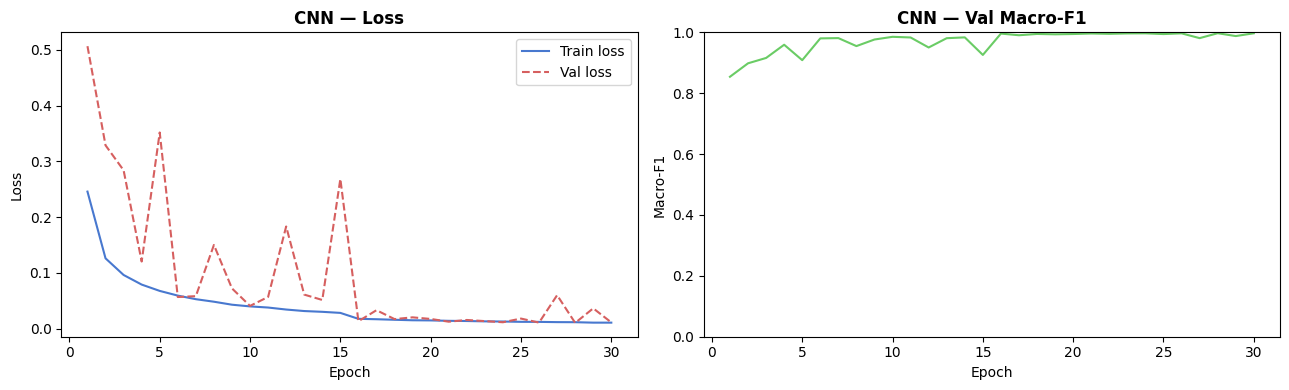

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_cnn_history.png


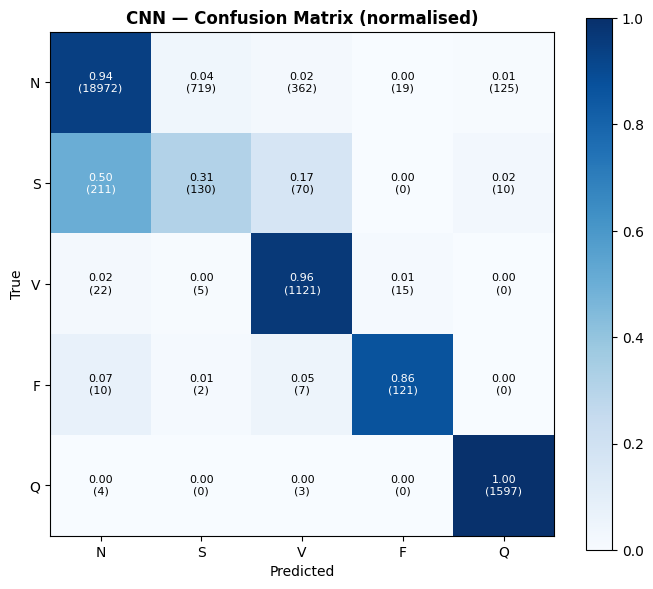

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_cnn_cm.png


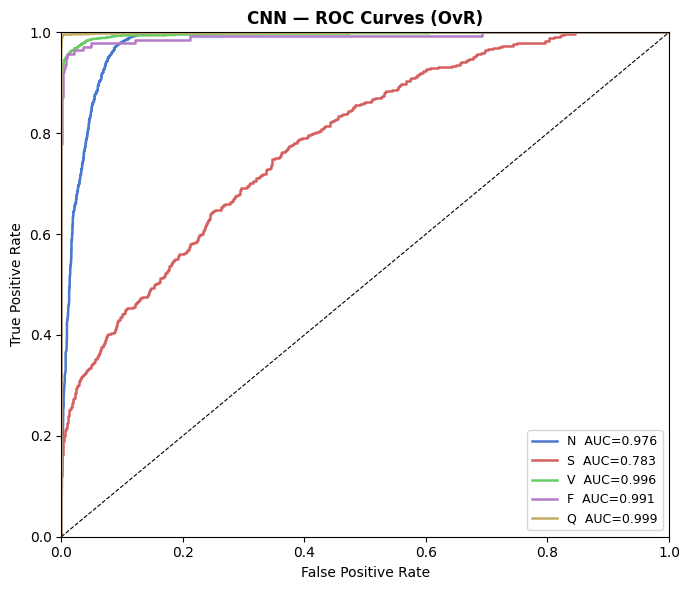

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_cnn_roc.png


In [9]:
# E6c — Evaluate CNN
# ──────────────────────────────────────────────────────────────────────────

cnn_proba,  cnn_pred,cnn_cm, cnn_df, cnn_acc, cnn_mf1, cnn_auc = evaluate_model(
    cnn_model, X_test_dl, y_test, "CNN"
)

np.save(os.path.join(SAVE_DIR, "cnn_proba.npy"), cnn_proba)
plot_history(cnn_hist.history, "CNN")
plot_confusion_matrix(cnn_cm, "CNN")
plot_roc_curves(y_test, cnn_proba, "CNN")

## E7 — Model 2: BiLSTM (Bidirectional LSTM)

**Architecture rationale:**

| Block | Layers | Purpose |
|---|---|---|
| BiLSTM 1 | Bidirectional(LSTM(128, return_sequences=True)) | Capture forward + backward temporal dependencies |
| BiLSTM 2 | Bidirectional(LSTM(64)) | Compress to fixed-length context vector |
| Classifier | Dense(64) → Dropout → Softmax(5) | 5-class output |

**Why Bidirectional?** A standard (unidirectional) LSTM only sees past context when  
processing sample t. ECG QRS morphology is symmetric — the P-wave before and T-wave after  
the R-peak are equally diagnostic. The backward pass gives the network access to future  
samples, improving detection of the post-R T-wave when classifying the beat.

**Why two LSTM layers?** The first layer learns local rhythm patterns; the second  
summarises them into a global beat-level representation.

**Role in this study:** BiLSTM-only baseline (no CNN front-end, no attention) — used in the
ablation comparison (E9) to isolate the contribution of multi-scale feature extraction and
dual attention in the proposed model.

In [10]:
# E7 — Build, train, and evaluate BiLSTM
# ──────────────────────────────────────────────────────────────────────────

from tensorflow.keras import layers, models, optimizers

def build_bilstm(input_len=BEAT_LEN, n_classes=N_CLASSES, dropout=DL_DROPOUT):
    inp = layers.Input(shape=(input_len, 1), name="waveform_input")

    # BiLSTM stack
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True), name="bilstm1"
    )(inp)
    x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False), name="bilstm2"
    )(x)
    x = layers.Dropout(dropout)(x)

    # Classifier head
    x   = layers.Dense(64, activation="relu")(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = models.Model(inp, out, name="BiLSTM")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=DL_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

bilstm_model = build_bilstm()
bilstm_model.summary()
print(f"\n  Trainable parameters : {bilstm_model.count_params():,}")

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ waveform_input (InputLayer)     │ (None, 360, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm1 (Bidirectional)         │ (None, 360, 256)       │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 360, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm2 (Bidirectional)         │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,053 (1.17 MB)

 Trainable params: 306,053 (1.17 MB)

 Non-trainable params: 0 (0.00 B)


  Trainable parameters : 306,053


In [11]:
# Core imports and global constants shared across all Part notebooks
# ──────────────────────────────────────────────────────────────────────────

import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import wfdb
import tensorflow as tf

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ── AAMI five-class scheme (AAMI EC57:1998) ────────────────────────────────
AAMI_LABELS = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}
AAMI_COLORS = {
    "N": "#4878CF",   # blue
    "S": "#D65F5F",   # red   ← primary SMOTE target (rarest, clinically critical)
    "V": "#6ACC65",   # green
    "F": "#B47CC7",   # purple
    "Q": "#C4AD66",   # gold
}

# MIT-BIH annotation symbol → AAMI integer class
BEAT_MAP = {
    # N — Normal + bundle-branch variants
    "N": 0, "L": 0, "R": 0, "B": 0, "e": 0, "j": 0, "n": 0,
    # S — Supraventricular ectopic  (most imbalanced → S-SMOTE target)
    "A": 1, "a": 1, "J": 1, "S": 1,
    # V — Ventricular ectopic
    "V": 2, "E": 2,
    # F — Fusion
    "F": 3,
    # Q — Unclassifiable / paced
    "/": 4, "f": 4, "Q": 4, "?": 4,
}

# ── MIT-BIH inter-patient split (AAMI v4) ─────────────────────────────────
# DS1 → train  |  DS2 → test   (zero patient overlap — strict paradigm)
DS1_RECORDS = [101,106,108,109,112,114,115,116,118,119,
               122,124,201,203,205,207,208,209,215,220,
               223,230]
DS2_RECORDS = [100,103,105,111,113,117,121,123,200,202,
               210,212,213,214,219,221,222,228,231,232,
               233,234]

# ── Orphan records (excluded from de Chazal DS1/DS2 — contain paced beats) ─
# These 4 patients are NOT in either AAMI list but carry >99% of all Q-class
# (paced/unknown) beats in MIT-BIH. They MUST still be loaded and processed
# (see Part B), then handled via the force-split logic in Part D — they are
# simply excluded from the *standard* inter-patient train/test assignment.
ORPHAN_RECORDS = [102, 104, 107, 217]

# ── Signal / preprocessing constants ──────────────────────────────────────
FS        = 360      # sampling rate (Hz)
BEAT_LEN  = 360      # samples per beat window (1 s @ 360 Hz)
PRE_SAMP  = 100      # samples before R-peak
POST_SAMP = 260      # samples after  R-peak
BP_LOW    = 0.5      # bandpass lower cut-off (Hz)
BP_HIGH   = 45.0     # bandpass upper cut-off (Hz)
WAVELET   = "sym4"   # Symlet-4 wavelet for denoising

# ── EMD / feature constants ────────────────────────────────────────────────
N_IMFS     = 8       # IMFs extracted per beat
N_FEATURES = 67      # total EMD feature dimension
N_MRMR     = 40      # MRMR top-k kept for downstream use

# ── Deep learning constants (CNN / BiLSTM / CNN-BiLSTM) ───────────────────
N_CLASSES   = 5      # AAMI classes
DL_EPOCHS   = 5    # maximum training epochs (early stopping applies)
DL_BATCH    = 512    # mini-batch size
DL_LR       = 1e-3   # initial Adam learning rate
DL_PATIENCE = 10     # early-stopping patience (epochs without val-F1 gain)
DL_DROPOUT  = 0.3    # dropout rate used in all three architectures

print("✓ Global constants defined")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  AAMI classes: {AAMI_LABELS}")
print(f"  DS1 (train) : {len(DS1_RECORDS)} patients")
print(f"  DS2 (test)  : {len(DS2_RECORDS)} patients")
print(f"  Orphan      : {len(ORPHAN_RECORDS)} patients  {ORPHAN_RECORDS}  (force-split in Part D)")
print(f"  Beat window : {BEAT_LEN} samples  ({BEAT_LEN/FS*1000:.0f} ms @ {FS} Hz)")
print(f"  EMD features: {N_FEATURES} dims  →  MRMR top-{N_MRMR}")
print(f"  DL settings : epochs={DL_EPOCHS}  batch={DL_BATCH}  lr={DL_LR}  patience={DL_PATIENCE}  dropout={DL_DROPOUT}")


✓ Global constants defined
  TensorFlow  : 2.21.0
  AAMI classes: {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'Q'}
  DS1 (train) : 22 patients
  DS2 (test)  : 22 patients
  Orphan      : 4 patients  [102, 104, 107, 217]  (force-split in Part D)
  Beat window : 360 samples  (1000 ms @ 360 Hz)
  EMD features: 67 dims  →  MRMR top-40
  DL settings : epochs=5  batch=512  lr=0.001  patience=10  dropout=0.3


In [12]:
print("Model output shape:", bilstm_model.output_shape)
print("y_tr_oh shape:", y_tr_oh.shape)
print("y_val_oh shape:", y_val_oh.shape)
print("NUM_CLASSES:", NUM_CLASSES if 'NUM_CLASSES' in dir() else "not defined")

Model output shape: (None, 5)
y_tr_oh shape: (316710, 5)
y_val_oh shape: (35190, 5)
NUM_CLASSES: not defined


In [13]:
# E7b — Train BiLSTM
# ──────────────────────────────────────────────────────────────────────────

bilstm_callbacks = get_callbacks("BiLSTM", X_val, y_val_int)

bilstm_hist = bilstm_model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=DL_EPOCHS,
    batch_size=DL_BATCH,
    callbacks=bilstm_callbacks,
    verbose=1,
)

bilstm_model.save(os.path.join(MODELS_DIR, "bilstm_model.keras"))
with open(os.path.join(SAVE_DIR, "bilstm_history.json"), "w") as f:
    json.dump(bilstm_hist.history, f)

print(f"\n✓ BiLSTM training complete — saved")
print(f"  Best val_macro_f1 : {max(bilstm_hist.history.get('val_macro_f1', [0])):.4f}")
print(f"  Epochs run        : {len(bilstm_hist.history['loss'])}")

Epoch 1/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 5410s 9s/step - accuracy: 0.8282 - loss: 0.4920 - val_accuracy: 0.9390 - val_loss: 0.1820 - val_macro_f1: 0.9390 - learning_rate: 0.0010
Epoch 2/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 6564s 11s/step - accuracy: 0.9353 - loss: 0.1993 - val_accuracy: 0.9569 - val_loss: 0.1292 - val_macro_f1: 0.9569 - learning_rate: 0.0010
Epoch 3/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 5752s 9s/step - accuracy: 0.9463 - loss: 0.1667 - val_accuracy: 0.9654 - val_loss: 0.0985 - val_macro_f1: 0.9654 - learning_rate: 0.0010
Epoch 4/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 5637s 9s/step - accuracy: 0.9639 - loss: 0.1144 - val_accuracy: 0.9742 - val_loss: 0.0788 - val_macro_f1: 0.9742 - learning_rate: 0.0010
Epoch 5/5
619/619 ━━━━━━━━━━━━━━━━━━━━ 4133s 7s/step - accuracy: 0.9690 - loss: 0.0986 - val_accuracy: 0.9761 - val_loss: 0.0680 - val_macro_f1: 0.9761 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✓ BiLSTM training complete — saved
  Best val_macro_f1 : 0.


  BiLSTM — Test Set Results
  Accuracy   : 72.43%
  Macro-F1   : 0.5161
  Macro-AUC  : 0.9366

  Class       Se      Sp     PPV      F1
  ------------------------------------
  N       0.6929  0.9663  0.9921  0.8159
  S       0.5558  0.8673  0.0709  0.1257
  V       0.9458  0.9009  0.3317  0.4912
  F       0.8857  0.9737  0.1676  0.2818
  Q       0.9894  0.9784  0.7700  0.8660



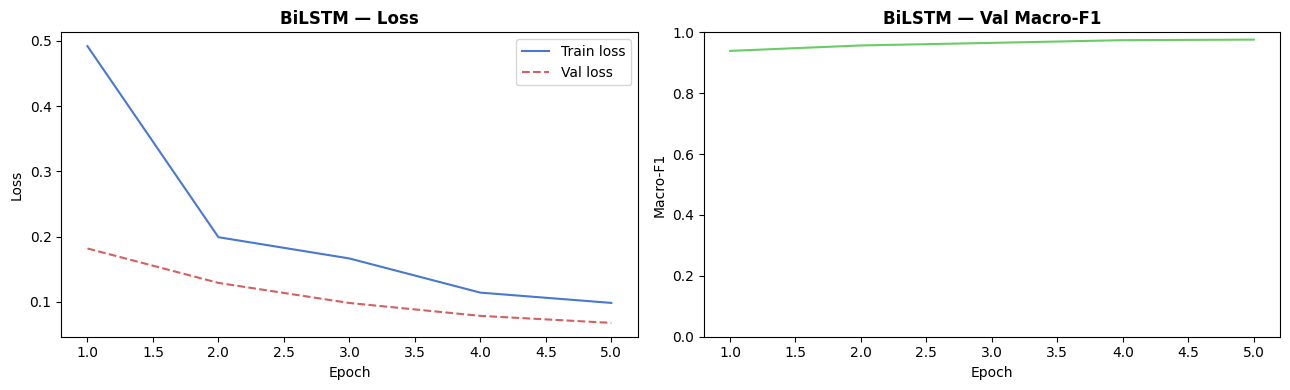

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_bilstm_history.png


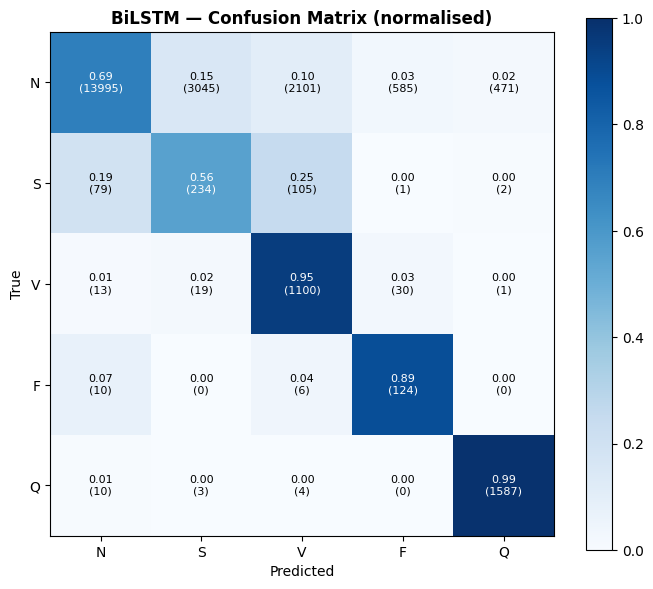

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_bilstm_cm.png


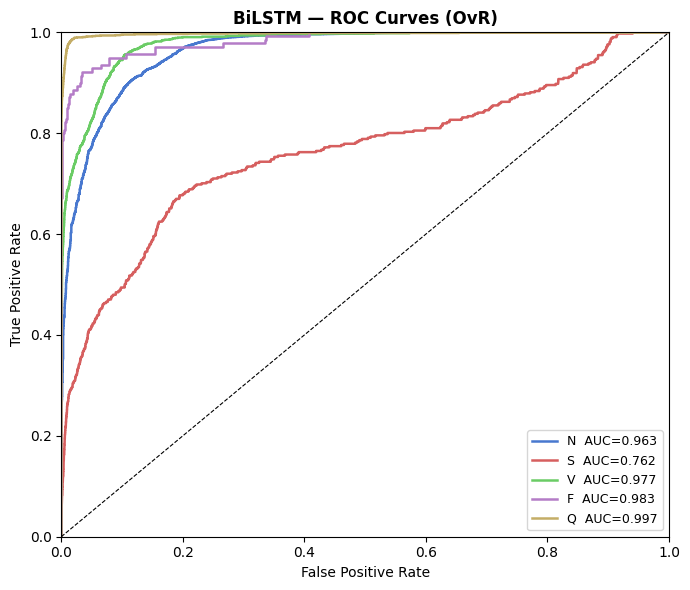

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_bilstm_roc.png


In [14]:
# E7c — Evaluate BiLSTM
# ──────────────────────────────────────────────────────────────────────────

bilstm_proba, bilstm_pred, bilstm_cm, bilstm_df, bilstm_acc, bilstm_mf1, bilstm_auc = evaluate_model(
    bilstm_model, X_test_dl, y_test, "BiLSTM"
)

np.save(os.path.join(SAVE_DIR, "bilstm_proba.npy"), bilstm_proba)
plot_history(bilstm_hist.history, "BiLSTM")
plot_confusion_matrix(bilstm_cm, "BiLSTM")
plot_roc_curves(y_test, bilstm_proba, "BiLSTM")

## E8 — Model 3: Multi-Scale CNN-BiLSTM with Dual Attention (Proposed Model)

**Architecture rationale — multi-scale feature extraction + dual attention + temporal modelling:**

| Block | Layers | Purpose |
|---|---|---|
| Multi-scale CNN | 3 parallel Conv1D branches: k=3 (32ch), k=7 (32ch), k=15 (32ch) | Capture fine QRS detail (k=3), P/T-wave shape (k=7), and overall beat morphology (k=15) simultaneously |
| Fusion | Concatenate branches → BN → MaxPool(2) | Combine multi-resolution features into one 96-channel feature map |
| Channel Attention | Squeeze-Excitation block (GAP + GMP → shared MLP → sigmoid) | Learns *which feature channels* matter most per beat |
| Temporal Attention | Dense(1) scoring + softmax over time steps → weighted context | Learns *which time steps* in the beat matter most (replaces channel-only SE/CBAM seen in prior work) |
| BiLSTM 1 | Bidirectional(LSTM(128, return_sequences=True)) | Sequential context over the attention-refined feature map |
| BiLSTM 2 | Bidirectional(LSTM(64)) | Global beat-level context vector |
| Classifier | Dense(64) → Dropout → Softmax(5) | 5-class output |

This is the paper's proposed model — **An Efficient Multi-Scale CNN-BiLSTM with Dual Attention
Mechanism for Real-Time Cardiac Arrhythmia Classification**. The multi-scale CNN replaces the
prior single-scale Conv1D(k=16)→Conv1D(k=8) stack with three parallel branches spanning a wider
kernel range (3–15), motivated by Zhou et al. (FCBA, 2024) and Reddy et al. (MS-CLDNet, 2025), both
of whom showed multi-scale convolution improves ECG feature extraction over single-scale CNN.

The **dual attention** block — channel attention *and* temporal attention — is the model's core
novel contribution. Channel attention (Squeeze-Excitation style, as in Sun et al. CNN-LSTM-SE and
Islam et al. CAT-Net) reweights *which learned features* matter; temporal attention reweights
*which time steps* matter, which is more appropriate for 1-D ECG sequences than the spatial
attention used in CBAM-style models (Najia & Faouzi explicitly found spatial attention "less
effective for 1D ECG"). Combining both — rather than channel attention alone — is supported by
Lyu et al. (DA-Net, 2023), who showed a second attention type adds +0.48% accuracy over channel
attention alone, with the largest gain on the hardest minority classes.

The model still uses BiLSTM (not BiGRU, as in Bai et al. CBGM) for richer long-range memory via
its three-gate structure, and reports model size + inference time below to support the paper's
real-time efficiency claim — the gap explicitly left open by Bai et al., Islam et al. (CAT-Net),
and Gupta et al.'s 2024 survey.

In [15]:
# E8 — Build, train, and evaluate Multi-Scale CNN-BiLSTM with Dual Attention
# ──────────────────────────────────────────────────────────────────────────
# Proposed model for: "An Efficient Multi-Scale CNN-BiLSTM with Dual Attention
# Mechanism for Real-Time Cardiac Arrhythmia Classification."
#
# Function name and output variable (cnn_bilstm_model) are kept identical to
# the previous single-scale version so Part F (ensembling/Optuna/SHAP) and
# Part G (INCART external validation) continue to work without any changes.

from tensorflow.keras import layers, models, optimizers
import tensorflow as tf


def channel_attention_block(x, name_prefix, reduction_ratio=8):
    """Squeeze-Excitation style channel attention.
    Learns which feature CHANNELS matter most, using both global average
    and global max pooling (richer than GAP-only SE)."""
    channels = x.shape[-1]

    avg_pool = layers.GlobalAveragePooling1D(name=f"{name_prefix}_gap")(x)
    max_pool = layers.GlobalMaxPooling1D(name=f"{name_prefix}_gmp")(x)

    shared_dense1 = layers.Dense(max(channels // reduction_ratio, 4), activation="relu",
                                  name=f"{name_prefix}_fc1")
    shared_dense2 = layers.Dense(channels, activation=None,
                                  name=f"{name_prefix}_fc2")

    avg_out = shared_dense2(shared_dense1(avg_pool))
    max_out = shared_dense2(shared_dense1(max_pool))

    channel_weights = layers.Activation("sigmoid", name=f"{name_prefix}_sigmoid")(
        layers.Add(name=f"{name_prefix}_add")([avg_out, max_out])
    )
    channel_weights = layers.Reshape((1, channels), name=f"{name_prefix}_reshape")(channel_weights)

    return layers.Multiply(name=f"{name_prefix}_scale")([x, channel_weights])


def temporal_attention_block(x, name_prefix):
    """Learns which TIME STEPS matter most along the sequence axis.
    More appropriate for 1-D ECG sequences than the spatial (2-D) attention
    used in CBAM-style models, which Najia & Faouzi (2025) found to be
    "less effective for 1D ECG signals." Returns a sequence re-weighted by
    per-timestep importance — NOT a collapsed vector — so BiLSTM still
    receives a full sequence."""
    # score(t) for every timestep, shared across channels
    scores = layers.Dense(1, activation=None, name=f"{name_prefix}_score")(x)   # (T, 1)
    weights = layers.Softmax(axis=1, name=f"{name_prefix}_softmax")(scores)     # (T, 1)
    return layers.Multiply(name=f"{name_prefix}_apply")([x, weights])           # (T, C) re-weighted


def build_cnn_bilstm(input_len=BEAT_LEN, n_classes=N_CLASSES, dropout=DL_DROPOUT):
    inp = layers.Input(shape=(input_len, 1), name="waveform_input")

    # ── Multi-scale CNN: 3 parallel branches at different receptive fields ──
    # k=3  -> fine QRS detail        k=7  -> P/T-wave shape
    # k=15 -> overall beat morphology
    branch_k3 = layers.Conv1D(32, kernel_size=3, padding="same", name="branch_k3_conv")(inp)
    branch_k3 = layers.BatchNormalization(name="branch_k3_bn")(branch_k3)
    branch_k3 = layers.Activation("relu", name="branch_k3_relu")(branch_k3)

    branch_k7 = layers.Conv1D(32, kernel_size=7, padding="same", name="branch_k7_conv")(inp)
    branch_k7 = layers.BatchNormalization(name="branch_k7_bn")(branch_k7)
    branch_k7 = layers.Activation("relu", name="branch_k7_relu")(branch_k7)

    branch_k15 = layers.Conv1D(32, kernel_size=15, padding="same", name="branch_k15_conv")(inp)
    branch_k15 = layers.BatchNormalization(name="branch_k15_bn")(branch_k15)
    branch_k15 = layers.Activation("relu", name="branch_k15_relu")(branch_k15)

    x = layers.Concatenate(name="multiscale_concat")([branch_k3, branch_k7, branch_k15])  # (360, 96)
    x = layers.BatchNormalization(name="fusion_bn")(x)
    x = layers.MaxPooling1D(pool_size=2, name="fusion_pool")(x)        # 360 → 180

    # Second multi-scale refinement stage (deeper features, same 3-scale idea)
    branch2_k3  = layers.Conv1D(64, kernel_size=3,  padding="same", activation="relu", name="branch2_k3")(x)
    branch2_k7  = layers.Conv1D(64, kernel_size=7,  padding="same", activation="relu", name="branch2_k7")(x)
    branch2_k15 = layers.Conv1D(64, kernel_size=15, padding="same", activation="relu", name="branch2_k15")(x)
    x = layers.Concatenate(name="multiscale2_concat")([branch2_k3, branch2_k7, branch2_k15])  # (180, 192)
    x = layers.BatchNormalization(name="fusion2_bn")(x)
    x = layers.MaxPooling1D(pool_size=2, name="fusion2_pool")(x)       # 180 → 90

    # ── Dual Attention: channel attention + temporal attention ──────────────
    x = channel_attention_block(x, name_prefix="ch_attn")
    x = temporal_attention_block(x, name_prefix="temp_attn")

    # ── BiLSTM temporal modelling over attention-refined feature map ───────
    x = layers.Bidirectional(
        layers.LSTM(128, return_sequences=True), name="bilstm1"
    )(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False), name="bilstm2"
    )(x)
    x = layers.Dropout(dropout)(x)

    # ── Classifier head ─────────────────────────────────────────────────────
    x   = layers.Dense(64, activation="relu")(x)
    x   = layers.Dropout(dropout)(x)
    out = layers.Dense(n_classes, activation="softmax", name="output")(x)

    model = models.Model(inp, out, name="MS_CNN_BiLSTM_DualAttention")
    model.compile(
        optimizer=optimizers.Adam(learning_rate=DL_LR),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


cnn_bilstm_model = build_cnn_bilstm()
cnn_bilstm_model.summary()
print(f"\n  Trainable parameters : {cnn_bilstm_model.count_params():,}")

# ── Efficiency metrics for the paper's real-time deployment claim ─────────
import time as _time

model_size_mb = sum(
    tf.size(w).numpy() * tf.as_dtype(w.dtype).size for w in cnn_bilstm_model.trainable_weights
) / (1024 ** 2)
print(f"  Approx. model size    : {model_size_mb:.2f} MB (trainable weights, float32)")

_dummy = tf.random.normal((1, BEAT_LEN, 1))
_ = cnn_bilstm_model.predict(_dummy, verbose=0)   # warm-up (build graph / autotune)
_t0 = _time.perf_counter()
N_TIMING_RUNS = 100
for _ in range(N_TIMING_RUNS):
    _ = cnn_bilstm_model.predict(_dummy, verbose=0)
_avg_inference_ms = (_time.perf_counter() - _t0) / N_TIMING_RUNS * 1000

print(f"  Approx. model size    : {model_size_mb:.2f} MB (trainable weights, float32)")
print(f"  Avg. inference time   : {_avg_inference_ms:.2f} ms / beat (single-sample, CPU/GPU as available)")


Model: "MS_CNN_BiLSTM_DualAttention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ waveform_input      │ (None, 360, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k3_conv      │ (None, 360, 32)   │        128 │ waveform_input[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k7_conv      │ (None, 360, 32)   │        256 │ waveform_input[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k15_conv     │ (None, 360, 32)   │        512 │ waveform_input[0… │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k3_bn        │ (None, 360, 32)   │        128 │ branch_k3_conv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k7_bn        │ (None, 360, 32)   │        128 │ branch_k7_conv[0… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k15_bn       │ (None, 360, 32)   │        128 │ branch_k15_conv[… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k3_relu      │ (None, 360, 32)   │          0 │ branch_k3_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k7_relu      │ (None, 360, 32)   │          0 │ branch_k7_bn[0][… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch_k15_relu     │ (None, 360, 32)   │          0 │ branch_k15_bn[0]… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale_concat   │ (None, 360, 96)   │          0 │ branch_k3_relu[0… │
│ (Concatenate)       │                   │            │ branch_k7_relu[0… │
│                     │                   │            │ branch_k15_relu[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_bn           │ (None, 360, 96)   │        384 │ multiscale_conca… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_pool         │ (None, 180, 96)   │          0 │ fusion_bn[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k3 (Conv1D) │ (None, 180, 64)   │     18,496 │ fusion_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k7 (Conv1D) │ (None, 180, 64)   │     43,072 │ fusion_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ branch2_k15         │ (None, 180, 64)   │     92,224 │ fusion_pool[0][0] │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiscale2_concat  │ (None, 180, 192)  │          0 │ branch2_k3[0][0], │
│ (Concatenate)       │                   │            │ branch2_k7[0][0]

 Total params: 667,486 (2.55 MB)

 Trainable params: 666,718 (2.54 MB)

 Non-trainable params: 768 (3.00 KB)


  Trainable parameters : 667,486
  Approx. model size    : 2.54 MB (trainable weights, float32)
  Approx. model size    : 2.54 MB (trainable weights, float32)
  Avg. inference time   : 138.61 ms / beat (single-sample, CPU/GPU as available)


In [16]:
# Core imports and global constants shared across all Part notebooks
# ──────────────────────────────────────────────────────────────────────────

import os
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import wfdb
import tensorflow as tf

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ── AAMI five-class scheme (AAMI EC57:1998) ────────────────────────────────
AAMI_LABELS = {0: "N", 1: "S", 2: "V", 3: "F", 4: "Q"}
AAMI_COLORS = {
    "N": "#4878CF",   # blue
    "S": "#D65F5F",   # red   ← primary SMOTE target (rarest, clinically critical)
    "V": "#6ACC65",   # green
    "F": "#B47CC7",   # purple
    "Q": "#C4AD66",   # gold
}

# MIT-BIH annotation symbol → AAMI integer class
BEAT_MAP = {
    # N — Normal + bundle-branch variants
    "N": 0, "L": 0, "R": 0, "B": 0, "e": 0, "j": 0, "n": 0,
    # S — Supraventricular ectopic  (most imbalanced → S-SMOTE target)
    "A": 1, "a": 1, "J": 1, "S": 1,
    # V — Ventricular ectopic
    "V": 2, "E": 2,
    # F — Fusion
    "F": 3,
    # Q — Unclassifiable / paced
    "/": 4, "f": 4, "Q": 4, "?": 4,
}

# ── MIT-BIH inter-patient split (AAMI v4) ─────────────────────────────────
# DS1 → train  |  DS2 → test   (zero patient overlap — strict paradigm)
DS1_RECORDS = [101,106,108,109,112,114,115,116,118,119,
               122,124,201,203,205,207,208,209,215,220,
               223,230]
DS2_RECORDS = [100,103,105,111,113,117,121,123,200,202,
               210,212,213,214,219,221,222,228,231,232,
               233,234]

# ── Orphan records (excluded from de Chazal DS1/DS2 — contain paced beats) ─
# These 4 patients are NOT in either AAMI list but carry >99% of all Q-class
# (paced/unknown) beats in MIT-BIH. They MUST still be loaded and processed
# (see Part B), then handled via the force-split logic in Part D — they are
# simply excluded from the *standard* inter-patient train/test assignment.
ORPHAN_RECORDS = [102, 104, 107, 217]

# ── Signal / preprocessing constants ──────────────────────────────────────
FS        = 360      # sampling rate (Hz)
BEAT_LEN  = 360      # samples per beat window (1 s @ 360 Hz)
PRE_SAMP  = 100      # samples before R-peak
POST_SAMP = 260      # samples after  R-peak
BP_LOW    = 0.5      # bandpass lower cut-off (Hz)
BP_HIGH   = 45.0     # bandpass upper cut-off (Hz)
WAVELET   = "sym4"   # Symlet-4 wavelet for denoising

# ── EMD / feature constants ────────────────────────────────────────────────
N_IMFS     = 8       # IMFs extracted per beat
N_FEATURES = 67      # total EMD feature dimension
N_MRMR     = 40      # MRMR top-k kept for downstream use

# ── Deep learning constants (CNN / BiLSTM / CNN-BiLSTM) ───────────────────
N_CLASSES   = 5      # AAMI classes
DL_EPOCHS   = 5    # maximum training epochs (early stopping applies)
DL_BATCH    = 128    # mini-batch size
DL_LR       = 1e-3   # initial Adam learning rate
DL_PATIENCE = 10     # early-stopping patience (epochs without val-F1 gain)
DL_DROPOUT  = 0.3    # dropout rate used in all three architectures

print("✓ Global constants defined")
print(f"  TensorFlow  : {tf.__version__}")
print(f"  AAMI classes: {AAMI_LABELS}")
print(f"  DS1 (train) : {len(DS1_RECORDS)} patients")
print(f"  DS2 (test)  : {len(DS2_RECORDS)} patients")
print(f"  Orphan      : {len(ORPHAN_RECORDS)} patients  {ORPHAN_RECORDS}  (force-split in Part D)")
print(f"  Beat window : {BEAT_LEN} samples  ({BEAT_LEN/FS*1000:.0f} ms @ {FS} Hz)")
print(f"  EMD features: {N_FEATURES} dims  →  MRMR top-{N_MRMR}")
print(f"  DL settings : epochs={DL_EPOCHS}  batch={DL_BATCH}  lr={DL_LR}  patience={DL_PATIENCE}  dropout={DL_DROPOUT}")


✓ Global constants defined
  TensorFlow  : 2.21.0
  AAMI classes: {0: 'N', 1: 'S', 2: 'V', 3: 'F', 4: 'Q'}
  DS1 (train) : 22 patients
  DS2 (test)  : 22 patients
  Orphan      : 4 patients  [102, 104, 107, 217]  (force-split in Part D)
  Beat window : 360 samples  (1000 ms @ 360 Hz)
  EMD features: 67 dims  →  MRMR top-40
  DL settings : epochs=5  batch=128  lr=0.001  patience=10  dropout=0.3


In [17]:
# E8b — Train CNN-BiLSTM
# ──────────────────────────────────────────────────────────────────────────

cnn_bilstm_callbacks = get_callbacks("CNN-BiLSTM", X_val, y_val_int)

cnn_bilstm_hist = cnn_bilstm_model.fit(
    X_tr, y_tr_oh,
    validation_data=(X_val, y_val_oh),
    epochs=DL_EPOCHS,
    batch_size=DL_BATCH,
    callbacks=cnn_bilstm_callbacks,
    verbose=1,
)

cnn_bilstm_model.save(os.path.join(MODELS_DIR, "cnn_bilstm_model.keras"))
with open(os.path.join(SAVE_DIR, "cnn_bilstm_history.json"), "w") as f:
    json.dump(cnn_bilstm_hist.history, f)

print(f"\n✓ CNN-BiLSTM training complete — saved")
print(f"  Best val_macro_f1 : {max(cnn_bilstm_hist.history.get('val_macro_f1', [0])):.4f}")
print(f"  Epochs run        : {len(cnn_bilstm_hist.history['loss'])}")

Epoch 1/5
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 2616s 1s/step - accuracy: 0.9316 - loss: 0.2088 - val_accuracy: 0.9731 - val_loss: 0.0817 - val_macro_f1: 0.9732 - learning_rate: 0.0010
Epoch 2/5
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 2450s 990ms/step - accuracy: 0.9749 - loss: 0.0801 - val_accuracy: 0.9824 - val_loss: 0.0540 - val_macro_f1: 0.9824 - learning_rate: 0.0010
Epoch 3/5
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 2531s 1s/step - accuracy: 0.9818 - loss: 0.0557 - val_accuracy: 0.9749 - val_loss: 0.0742 - val_macro_f1: 0.9749 - learning_rate: 0.0010
Epoch 4/5
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 2945s 1s/step - accuracy: 0.9866 - loss: 0.0423 - val_accuracy: 0.9883 - val_loss: 0.0392 - val_macro_f1: 0.9883 - learning_rate: 0.0010
Epoch 5/5
2475/2475 ━━━━━━━━━━━━━━━━━━━━ 2494s 1s/step - accuracy: 0.9892 - loss: 0.0337 - val_accuracy: 0.9899 - val_loss: 0.0319 - val_macro_f1: 0.9898 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

✓ CNN-BiLSTM training complete — saved
  Best v

In [18]:
# Diagnostic — run this before E8c
print("cnn_bilstm_hist" in dir())      # Should be True
print("cnn_bilstm_model" in dir())     # Should be True
print("X_test_dl" in dir())            # Should be True

True
True
True



  CNN-BiLSTM — Test Set Results
  Accuracy   : 82.62%
  Macro-F1   : 0.5801
  Macro-AUC  : 0.9379

  Class       Se      Sp     PPV      F1
  ------------------------------------
  N       0.8156  0.9363  0.9873  0.8933
  S       0.3278  0.9698  0.1651  0.2196
  V       0.9475  0.9208  0.3836  0.5461
  F       0.9214  0.9900  0.3544  0.5119
  Q       0.9944  0.9465  0.5762  0.7296



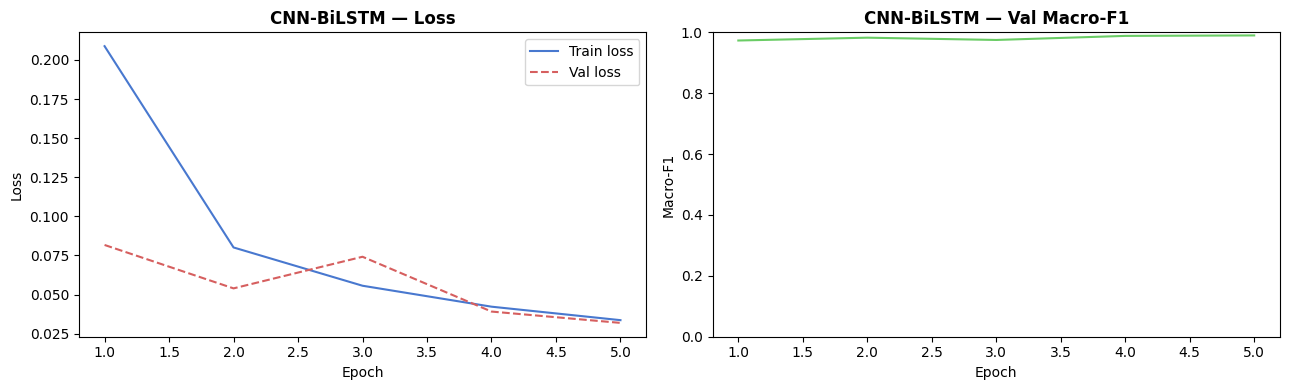

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_cnn_bilstm_history.png


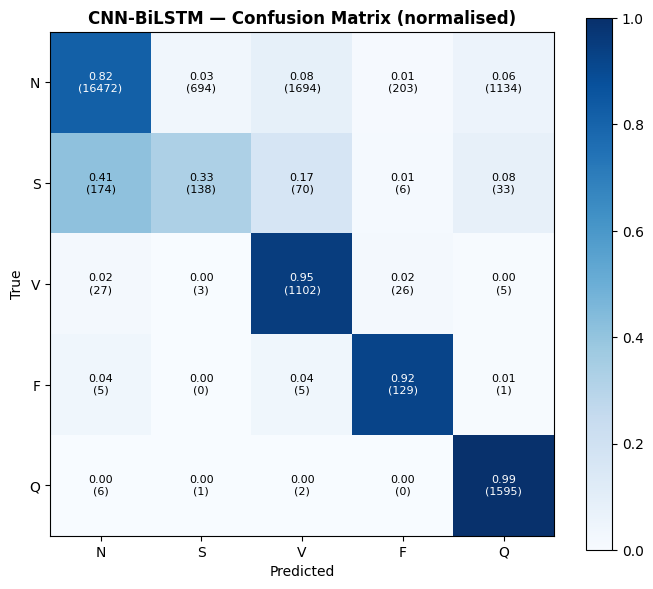

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_cnn_bilstm_cm.png


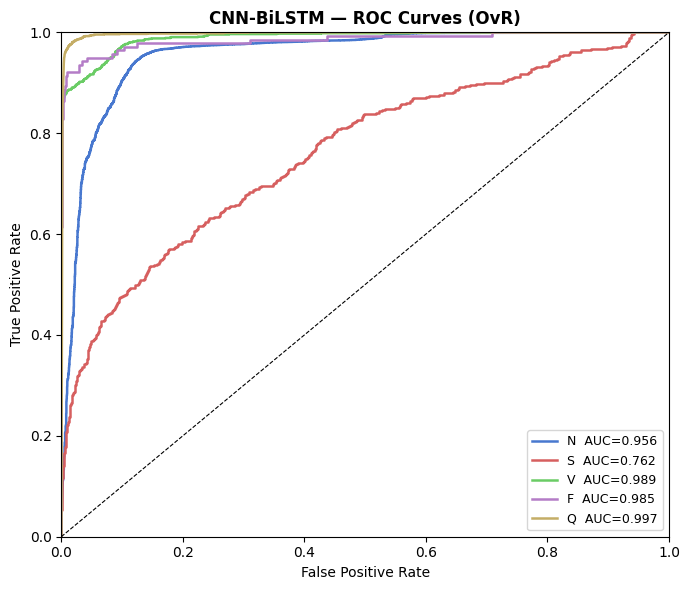

  Saved: D:\Downloads\ecg_project_complete\ecg_project\figures\E_cnn_bilstm_roc.png


In [19]:
# E8c — Evaluate CNN-BiLSTM
# ──────────────────────────────────────────────────────────────────────────

cnn_bilstm_proba, cnn_bilstm_pred, cnn_bilstm_cm, cnn_bilstm_df, \
    cnn_bilstm_acc, cnn_bilstm_mf1, cnn_bilstm_auc = evaluate_model(
    cnn_bilstm_model, X_test_dl, y_test, "CNN-BiLSTM"
)

np.save(os.path.join(SAVE_DIR, "cnn_bilstm_proba.npy"), cnn_bilstm_proba)
plot_history(cnn_bilstm_hist.history, "CNN-BiLSTM")
plot_confusion_matrix(cnn_bilstm_cm, "CNN-BiLSTM")
plot_roc_curves(y_test, cnn_bilstm_proba, "CNN-BiLSTM")

## E9 — Comparative Results Table & Model Comparison Plots

In [20]:
# E9 — Side-by-side comparison of all three models
# ──────────────────────────────────────────────────────────────────────────

MODEL_NAMES  = ["CNN (baseline)", "BiLSTM (baseline)", "MS-CNN-BiLSTM-DualAttn (proposed)"]
MODEL_ACC    = [cnn_acc,        bilstm_acc,        cnn_bilstm_acc]
MODEL_MF1    = [cnn_mf1,        bilstm_mf1,        cnn_bilstm_mf1]
MODEL_AUC    = [cnn_auc,        bilstm_auc,         cnn_bilstm_auc]
MODEL_DFS    = [cnn_df,         bilstm_df,          cnn_bilstm_df]

# ── Summary table ──────────────────────────────────────────────────────────
print("\n" + "="*68)
print("  COMPARATIVE RESULTS SUMMARY")
print("="*68)
print(f"  {'Model':<14} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-AUC':>11}")
print("  " + "-"*48)
for name, acc, mf1, auc in zip(MODEL_NAMES, MODEL_ACC, MODEL_MF1, MODEL_AUC):
    print(f"  {name:<14} {acc*100:>9.2f}% {mf1:>10.4f} {auc:>11.4f}")
print("="*68)

# Per-class breakdown
print("\nPer-Class F1 Scores:")
print(f"  {'Class':<8}", end="")
for name in MODEL_NAMES:
    print(f"  {name:>12}", end="")
print()
print("  " + "-" * (8 + 14*len(MODEL_NAMES)))
for k in range(N_CLASSES):
    print(f"  {AAMI_LABELS[k]:<8}", end="")
    for df_ in MODEL_DFS:
        f1 = df_.loc[df_["Class"] == AAMI_LABELS[k], "F1"].values[0]
        print(f"  {f1:>12.4f}", end="")
    print()

# Save full metrics CSV
all_rows = []
for name, df_ in zip(MODEL_NAMES, MODEL_DFS):
    df_["Model"] = name
    all_rows.append(df_)
metrics_df = pd.concat(all_rows, ignore_index=True)
metrics_df.to_csv(os.path.join(SAVE_DIR, "E_metrics_summary.csv"), index=False)
print(f"\n✓ Metrics saved → {os.path.join(SAVE_DIR, 'E_metrics_summary.csv')}")


  COMPARATIVE RESULTS SUMMARY
  Model            Accuracy   Macro-F1   Macro-AUC
  ------------------------------------------------
  CNN (baseline)     93.27%     0.7533      0.9492
  BiLSTM (baseline)     72.43%     0.5161      0.9366
  MS-CNN-BiLSTM-DualAttn (proposed)     82.62%     0.5801      0.9379

Per-Class F1 Scores:
  Class     CNN (baseline)  BiLSTM (baseline)  MS-CNN-BiLSTM-DualAttn (proposed)
  --------------------------------------------------
  N               0.9627        0.8159        0.8933
  S               0.2036        0.1257        0.2196
  V               0.8225        0.4912        0.5461
  F               0.8203        0.2818        0.5119
  Q               0.9574        0.8660        0.7296

✓ Metrics saved → D:\Downloads\ecg_project_complete\ecg_project\results\E_metrics_summary.csv


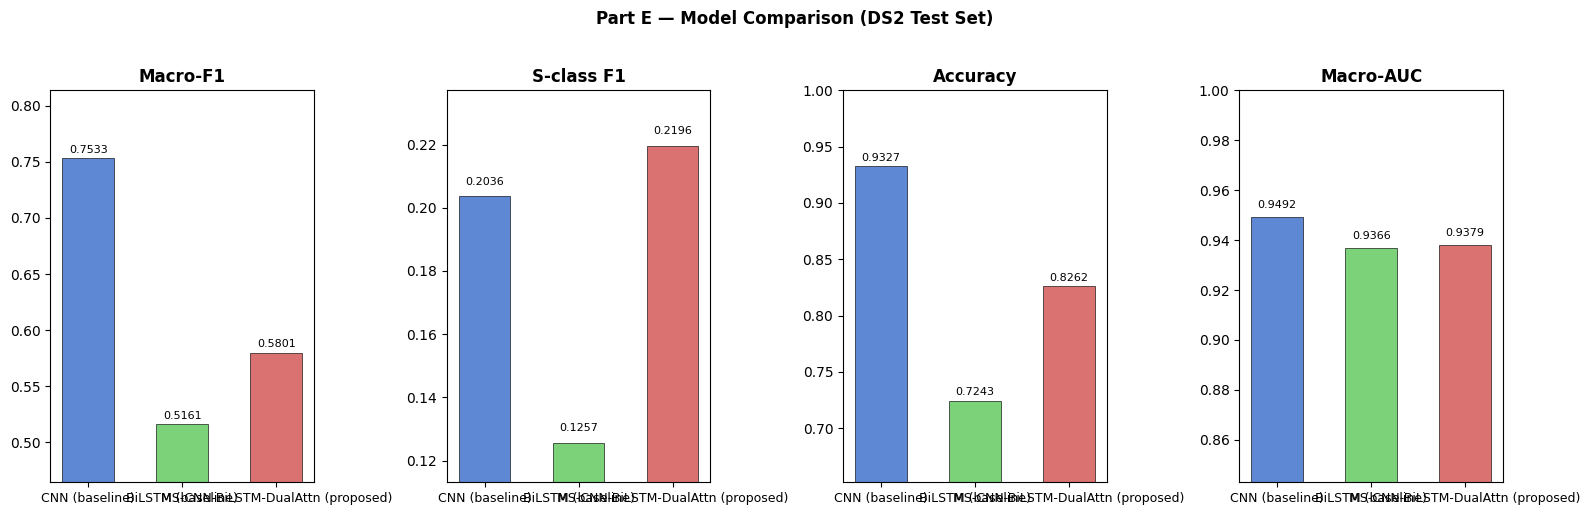

✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\E_model_comparison.png


In [21]:
# E9b — Comparison bar chart: Macro-F1, S-class F1, Accuracy, AUC
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
bar_colors = ["#4878CF", "#6ACC65", "#D65F5F"]
x          = np.arange(len(MODEL_NAMES))
w          = 0.55

metrics_plot = {
    "Macro-F1":    MODEL_MF1,
    "S-class F1":  [df_.loc[df_["Class"]=="S","F1"].values[0] for df_ in MODEL_DFS],
    "Accuracy":    MODEL_ACC,
    "Macro-AUC":   MODEL_AUC,
}

for ax, (metric_name, vals) in zip(axes, metrics_plot.items()):
    bars = ax.bar(x, vals, width=w, color=bar_colors, alpha=0.88, edgecolor="black", lw=0.5)
    ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES, fontsize=9)
    ax.set_title(metric_name, fontweight="bold")
    ax.set_ylim(max(0, min(vals)*0.9), min(1.0, max(vals)*1.08))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003, f"{val:.4f}",
                ha="center", va="bottom", fontsize=8)

plt.suptitle("Part E — Model Comparison (DS2 Test Set)", fontweight="bold", y=1.02)
plt.tight_layout()
out = os.path.join(FIGS_DIR, "E_model_comparison.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved {out}")

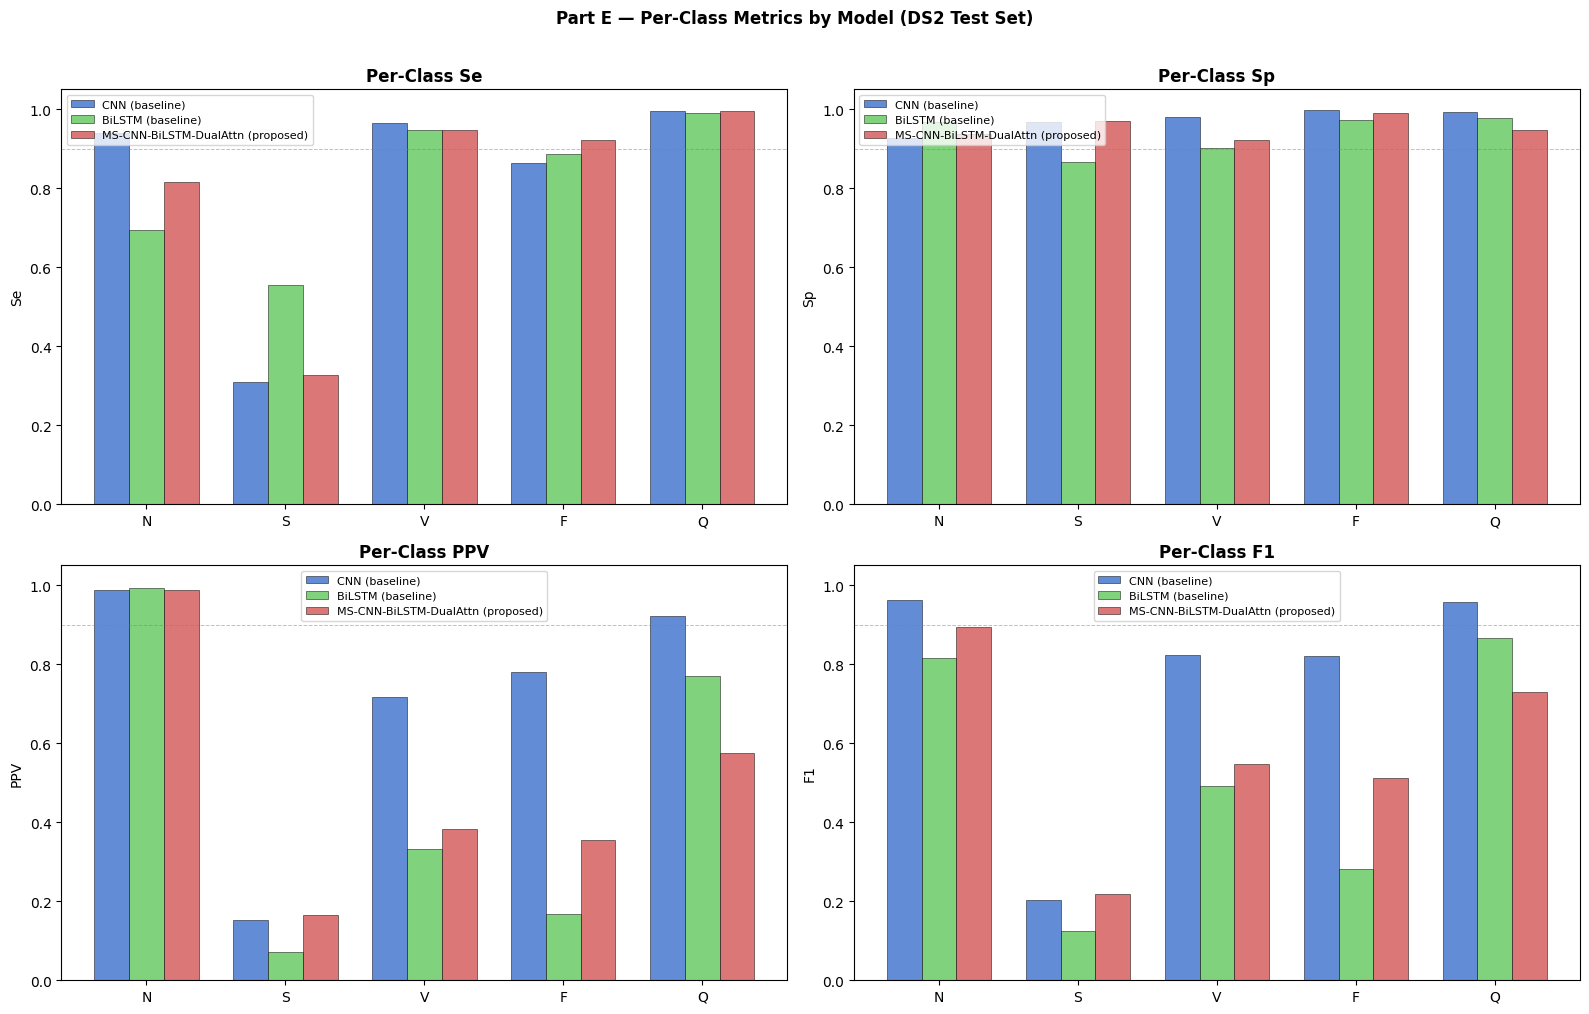

✓ Saved D:\Downloads\ecg_project_complete\ecg_project\figures\E_per_class_metrics.png


In [22]:
# E9c — Per-class Se/Sp/PPV/F1 grouped bar chart for all three models
# ──────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
metrics_cls = ["Se", "Sp", "PPV", "F1"]

x     = np.arange(N_CLASSES)
w     = 0.25
offsets = [-w, 0, w]
model_colors = ["#4878CF", "#6ACC65", "#D65F5F"]

for ax, metric in zip(axes, metrics_cls):
    for i, (name, df_, color) in enumerate(zip(MODEL_NAMES, MODEL_DFS, model_colors)):
        vals = [df_.loc[df_["Class"]==AAMI_LABELS[k], metric].values[0] for k in range(N_CLASSES)]
        ax.bar(x + offsets[i], vals, width=w, label=name, color=color, alpha=0.85,
               edgecolor="black", lw=0.4)
    ax.set_xticks(x)
    ax.set_xticklabels([AAMI_LABELS[k] for k in range(N_CLASSES)])
    ax.set_title(f"Per-Class {metric}", fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.axhline(0.9, color="grey", ls="--", lw=0.7, alpha=0.5)

plt.suptitle("Part E — Per-Class Metrics by Model (DS2 Test Set)", fontweight="bold", y=1.01)
plt.tight_layout()
out = os.path.join(FIGS_DIR, "E_per_class_metrics.png")
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Saved {out}")

## E10 — Save Predictions for Part F (Ensemble)

In [23]:
# E10 — Confirm all predictions and model files are saved for Part F
# ──────────────────────────────────────────────────────────────────────────

outputs = {
    "cnn_model.keras"       : os.path.join(MODELS_DIR, "cnn_model.keras"),
    "bilstm_model.keras"    : os.path.join(MODELS_DIR, "bilstm_model.keras"),
    "cnn_bilstm_model.keras": os.path.join(MODELS_DIR, "cnn_bilstm_model.keras"),
    "cnn_proba.npy"         : os.path.join(SAVE_DIR, "cnn_proba.npy"),
    "bilstm_proba.npy"      : os.path.join(SAVE_DIR, "bilstm_proba.npy"),
    "cnn_bilstm_proba.npy"  : os.path.join(SAVE_DIR, "cnn_bilstm_proba.npy"),
    "X_train_dl.npy"        : os.path.join(SAVE_DIR, "X_train_dl.npy"),
    "X_test_dl.npy"         : os.path.join(SAVE_DIR, "X_test_dl.npy"),
    "y_test.npy"            : os.path.join(SAVE_DIR, "y_test.npy"),
    "E_metrics_summary.csv" : os.path.join(SAVE_DIR, "E_metrics_summary.csv"),
}

print("Part E Output File Verification")
print("─" * 50)
all_ok = True
for name, path in outputs.items():
    exists = os.path.exists(path)
    size   = os.path.getsize(path) if exists else 0
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {name:<30} {size/1024:>8.1f} KB")
    if not exists:
        all_ok = False

print("─" * 50)
if all_ok:
    print("\n✓ All Part E outputs verified — ready for Part F")
else:
    print("\n⚠  Some files are missing — re-run the relevant cells")

Part E Output File Verification
──────────────────────────────────────────────────
  ✓  cnn_model.keras                  2901.2 KB
  ✓  bilstm_model.keras               3653.2 KB
  ✓  cnn_bilstm_model.keras           7996.7 KB
  ✓  cnn_proba.npy                     459.6 KB
  ✓  bilstm_proba.npy                  459.6 KB
  ✓  cnn_bilstm_proba.npy              459.6 KB
  ✓  X_train_dl.npy                 494859.5 KB
  ✓  X_test_dl.npy                   33082.2 KB
  ✓  y_test.npy                        183.9 KB
  ✓  E_metrics_summary.csv               1.8 KB
──────────────────────────────────────────────────

✓ All Part E outputs verified — ready for Part F


## E11 — Part E Summary & Next Steps

In [24]:
# E11 — Summary
# ──────────────────────────────────────────────────────────────────────────

best_model = MODEL_NAMES[np.argmax(MODEL_MF1)]
best_mf1   = max(MODEL_MF1)
best_s_f1  = max(
    df_.loc[df_["Class"]=="S","F1"].values[0]
    for df_ in MODEL_DFS
)

print("=" * 62)
print("  Part E Complete — Deep Learning Classifiers")
print("=" * 62)
print()
print("  ✓ Full-class balanced SMOTE applied to raw waveforms")
print(f"    Balanced training set : {len(y_sm):,} beats")
print()
print("  ✓ Three models trained and evaluated on DS2 (inter-patient):")
print()
print(f"  {'Model':<14} {'Accuracy':>10} {'Macro-F1':>10} {'Macro-AUC':>11}")
print("  " + "-" * 48)
for name, acc, mf1, auc in zip(MODEL_NAMES, MODEL_ACC, MODEL_MF1, MODEL_AUC):
    marker = "  ◀ best" if name == best_model else ""
    print(f"  {name:<14} {acc*100:>9.2f}% {mf1:>10.4f} {auc:>11.4f}{marker}")
print()
print(f"  Best overall model  : {best_model}  (Macro-F1 = {best_mf1:.4f})")
print(f"  Best S-class F1     : {best_s_f1:.4f}")
print()
print("  Models saved   → models/  (cnn / bilstm / cnn_bilstm)")
print("  Probabilities  → results/ (cnn_proba / bilstm_proba / cnn_bilstm_proba)")
print()
print("  Next  →  Part F: Ensemble · Optuna · SHAP")
print("             • Soft-voting & stacking ensemble")
print("             • Optuna hyperparameter tuning")
print("             • SHAP model explainability")
print("             • Literature benchmark comparison")
print()
print("=" * 62)

  Part E Complete — Deep Learning Classifiers

  ✓ Full-class balanced SMOTE applied to raw waveforms
    Balanced training set : 351,900 beats

  ✓ Three models trained and evaluated on DS2 (inter-patient):

  Model            Accuracy   Macro-F1   Macro-AUC
  ------------------------------------------------
  CNN (baseline)     93.27%     0.7533      0.9492  ◀ best
  BiLSTM (baseline)     72.43%     0.5161      0.9366
  MS-CNN-BiLSTM-DualAttn (proposed)     82.62%     0.5801      0.9379

  Best overall model  : CNN (baseline)  (Macro-F1 = 0.7533)
  Best S-class F1     : 0.2196

  Models saved   → models/  (cnn / bilstm / cnn_bilstm)
  Probabilities  → results/ (cnn_proba / bilstm_proba / cnn_bilstm_proba)

  Next  →  Part F: Ensemble · Optuna · SHAP
             • Soft-voting & stacking ensemble
             • Optuna hyperparameter tuning
             • SHAP model explainability
             • Literature benchmark comparison

